## 1. What this notebook computes

The self-consistency loop of density functional theory is a map from an input
density to an output density, and a solution is a fixed point of this map. The
simple loop "output becomes the next input" often fails. This notebook shows why,
with a model small enough to understand completely: two electrons on two sites. It

- runs the loop by diagonalising the $2 \times 2$ mean-field Hamiltonian and checks
  that it equals the reduced map $x_{out} = G(x)$ of one number;
- reproduces the tables of plain iteration (the density jumps between the two sites
  forever: charge sloshing) and of linear mixing with $\beta = 1/2$ (it converges);
- finds the fixed point by bisection, the slope $G'$ there, and the condition
  $0 < \beta < 2/(1 - G')$ under which linear mixing converges;
- compares the error histories of plain iteration, several linear mixings and
  Anderson mixing;
- maps the long-run behaviour of the loop against $\beta$ and the threshold against
  the repulsion $U$;
- draws six teaching plots.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 13d (Charge sloshing and mixing in the two-site model) is the file
`Revision/textbook/notebooks/13d_charge_sloshing.ipynb` of the repository Dirac_claude.
It runs the self-consistency loop of a two-site mean-field model with two electrons (site
energies -1 and +1, hopping 1, repulsion 4) by diagonalising its 2 x 2 Hamiltonian,
checks the reduced map x_out = G(x), reproduces the tables of plain iteration (charge
sloshing between the sites) and of linear mixing, finds the fixed point and the
convergence condition of linear mixing 0 < beta < 2/(1 - G'), compares plain iteration,
linear mixing and Anderson mixing (with the settings of the Revision Kohn-Sham solver,
read from its parameter file), maps the long-run behaviour against beta and the threshold
against the repulsion, and draws six teaching plots. It needs a computer with Windows 11,
macOS or Linux, an internet connection for the installation, the program Git, and Python
3.12 or newer (the notebooks were built with Python 3.14.5) with these packages at
exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0,
jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert
7.16.6. The notebook itself imports numpy and matplotlib; the other packages run Jupyter,
the program that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 13d_charge_sloshing.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 10 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 13d_charge_sloshing.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
13d_charge_sloshing.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/13d.captions.json`
- `Revision/textbook/figures/13d_1_reduced_map.png`
- `Revision/textbook/figures/13d_2_cobwebs.png`
- `Revision/textbook/figures/13d_3_error_histories.png`
- `Revision/textbook/figures/13d_4_convergence_factor.png`
- `Revision/textbook/figures/13d_5_long_run_diagram.png`
- `Revision/textbook/figures/13d_6_threshold_versus_u.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the figure file 13d_6_threshold_versus_u.png exists
    ALL 17 CHECKS PASSED (notebook 13d)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/13d_charge_sloshing.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" for `parameters.json`: the notebook reads the file
  `Revision/kohn_sham/results/parameters.json` of the repository; it must be opened
  inside the folder `Revision/textbook/notebooks` of a complete clone of the repository,
  not as a single downloaded file.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 13d (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 13d (Charge sloshing and mixing in the two-site model) is the file
# Revision/textbook/notebooks/13d_charge_sloshing.ipynb of the repository Dirac_claude.
# It runs the self-consistency loop of a two-site mean-field model with two electrons
# (site energies -1 and +1, hopping 1, repulsion 4) by diagonalising its 2 x 2
# Hamiltonian, checks the reduced map x_out = G(x), reproduces the tables of plain
# iteration (charge sloshing between the sites) and of linear mixing, finds the fixed
# point and the convergence condition of linear mixing 0 < beta < 2/(1 - G'), compares
# plain iteration, linear mixing and Anderson mixing (with the settings of the Revision
# Kohn-Sham solver, read from its parameter file), maps the long-run behaviour against
# beta and the threshold against the repulsion, and draws six teaching plots. It needs a
# computer with Windows 11, macOS or Linux, an internet connection for the installation,
# the program Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5)
# with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0,
# matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0
# and nbconvert 7.16.6. The notebook itself imports numpy and matplotlib; the other
# packages run Jupyter, the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 13d_charge_sloshing.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 10
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 13d_charge_sloshing.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 13d_charge_sloshing.ipynb (in the same folder, without running the cells again) to read
# the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/13d.captions.json
# - Revision/textbook/figures/13d_1_reduced_map.png
# - Revision/textbook/figures/13d_2_cobwebs.png
# - Revision/textbook/figures/13d_3_error_histories.png
# - Revision/textbook/figures/13d_4_convergence_factor.png
# - Revision/textbook/figures/13d_5_long_run_diagram.png
# - Revision/textbook/figures/13d_6_threshold_versus_u.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the figure file 13d_6_threshold_versus_u.png exists
#     ALL 17 CHECKS PASSED (notebook 13d)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/13d_charge_sloshing.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" for parameters.json: the notebook reads the file
#   Revision/kohn_sham/results/parameters.json of the repository; it must be opened
#   inside the folder Revision/textbook/notebooks of a complete clone of the repository,
#   not as a single downloaded file.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "13d"  # this notebook: chapter 13, example d


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 13d complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Two-site model**: two places L and R with one orbital each; an electron can hop
  between them (hopping $t$); the site energies are $-\Delta/2$ (L) and $+\Delta/2$
  (R).
- **Mean field**: each electron feels the other one only through its average
  density; here an electron on a site feels $U$ times the density of the other label
  on that site, i.e. $U n_L/2$ on L and $U n_R/2$ on R.
- **Density** $n_L$, $n_R = 2 - n_L$: the expected number of electrons on each site.
- **Fixed point** of a map $G$: a number $x^*$ with $G(x^*) = x^*$.
- **Plain iteration**: $x \leftarrow G(x)$; **linear mixing**:
  $x \leftarrow (1 - \beta)\,x + \beta\,G(x)$ with the mixing parameter $\beta$.
- **Charge sloshing**: the loop moves the charge back and forth between regions
  instead of settling.
- **Error**: the distance $x - x^*$ from the fixed point; **convergence factor**: the
  number by which one step multiplies the error near the fixed point.
- **Cobweb diagram**: a picture of an iteration: go vertically to the curve $G$,
  horizontally to the diagonal, vertically again, and so on.
- **Anderson mixing**: a mixing that uses several earlier steps to estimate the
  slope of $G$ (for one variable it is close to the secant method).
- **Bisection**: finding a root by halving an interval that contains it.

## 4. The physical and mathematical situation

Two electrons with opposite labels occupy the lowest orbital of the mean-field
Hamiltonian

$$h[n_L] = \begin{pmatrix} -\Delta/2 + U n_L/2 & -t \\ -t & \Delta/2 + U n_R/2
\end{pmatrix}, \qquad n_R = 2 - n_L,$$

so the output density is $n_L^{out} = 2|c_L|^2$, where $(c_L, c_R)$ is the
normalised lowest eigenvector. For a real symmetric matrix
$\begin{pmatrix} a & -t\\ -t & b\end{pmatrix}$ the lowest eigenvector has
$|c_L|^2 = \tfrac12\big(1 + (b - a)/\sqrt{(b - a)^2 + 4t^2}\big)$, and here
$b - a = \Delta + U(1 - n_L)$. With $x = n_L - 1$ (the excess on L) the whole loop is
one function of one number:

$$x_{out} = G(x) = \frac{\Delta - U x}{\sqrt{(\Delta - Ux)^2 + 4t^2}} .$$

Near the fixed point $x^*$, $G(x^* + e) \approx x^* + G'(x^*)\,e$, so linear mixing
multiplies the error by $1 - \beta(1 - G'(x^*))$ at every step, and it converges
exactly when this number lies between $-1$ and $1$, i.e. for
$0 < \beta < 2/(1 - G'(x^*))$. The slope is
$G'(x) = -4Ut^2/((\Delta - Ux)^2 + 4t^2)^{3/2}$.

**Numbers.** $\Delta = 2$, $t = 1$, $U = 4$ (energies in units of $t$), start
$n_L = 2$ (both electrons on the low site). **Status:** exact mathematics of a model
loop (COMPUTED here); the model shows the mechanism, not a physical system of the
book. Its only link to the Revision record is the Anderson-mixing settings, which
section 8 reads from the parameter file of the Revision Kohn-Sham solver.

## 5. The loop and the reduced map

The next cell defines one pass of the loop by diagonalising $h[n_L]$ with numpy, and
the closed-form map $G$, and checks that they agree for 41 inputs between 0 and 2.

In [2]:
import numpy as np  # arrays, matrices and linear algebra

DELTA, T_HOP, U = 2.0, 1.0, 4.0  # site-energy difference, hopping, repulsion


def loop_pass(n_left, delta=DELTA, t=T_HOP, u=U):
    """One pass: the output density n_L of the lowest orbital of h[n_L]."""
    n_right = 2.0 - n_left
    h = np.array([[-delta / 2 + u * n_left / 2, -t],
                  [-t, delta / 2 + u * n_right / 2]])
    values, vectors = np.linalg.eigh(h)  # levels in increasing order
    return 2.0 * vectors[0, 0] ** 2  # two electrons, |c_L|^2 each


def G(x, delta=DELTA, t=T_HOP, u=U):
    """The reduced map x_out = G(x), x = n_L - 1."""
    shift = delta - u * x
    return shift / np.sqrt(shift ** 2 + 4.0 * t * t)


inputs = np.linspace(0.0, 2.0, 41)
worst = max(abs(loop_pass(n) - 1.0 - G(n - 1.0)) for n in inputs)
check(worst < 1e-12, "the 2 x 2 diagonalisation and the reduced map G agree")

PASS the 2 x 2 diagonalisation and the reduced map G agree


The next cell finds the fixed point $x^*$ by bisection on $x - G(x)$, which increases
with $x$ (because $G$ decreases), computes the slope $G'(x^*)$ from the formula and
from a difference quotient, and the largest and the best mixing parameters,
$\beta_{max} = 2/(1 - G')$ and $\beta_{best} = 1/(1 - G')$ (which makes the factor
zero).

In [3]:
def fixed_point(delta=DELTA, t=T_HOP, u=U):
    """x* with G(x*) = x*, by bisection on [-1, 1] (x - G(x) increases)."""
    low, high = -1.0, 1.0
    for _ in range(80):
        middle = 0.5 * (low + high)
        if middle - G(middle, delta, t, u) > 0.0:
            high = middle
        else:
            low = middle
    return 0.5 * (low + high)


def slope(x, delta=DELTA, t=T_HOP, u=U):
    """G'(x) = -4 U t^2 / ((Delta - U x)^2 + 4 t^2)^(3/2)."""
    return -4.0 * u * t * t / ((delta - u * x) ** 2 + 4.0 * t * t) ** 1.5


x_star = fixed_point()
g_prime = slope(x_star)
quotient = (G(x_star + 1e-6) - G(x_star - 1e-6)) / 2e-6
beta_max, beta_best = 2.0 / (1.0 - g_prime), 1.0 / (1.0 - g_prime)
report("fixed point n_L* = 1 + x*", f"{1.0 + x_star:.6f}")
report("slope G'(x*)", f"{g_prime:.6f}")
report("largest mixing parameter 2/(1 - G')", f"{beta_max:.6f}")
report("best mixing parameter 1/(1 - G')", f"{beta_best:.6f}")
check(abs(x_star - 0.326993) < 1e-6 and abs(g_prime + 1.687961) < 1e-6
      and abs(beta_max - 0.744058) < 1e-6,
      "x* = 0.326993, G'(x*) = -1.687961, beta_max = 0.744058")
check(abs(quotient - g_prime) < 1e-6, "the slope formula equals a difference quotient")

RESULT fixed point n_L* = 1 + x* = 1.326993
RESULT slope G'(x*) = -1.687961
RESULT largest mixing parameter 2/(1 - G') = 0.744058
RESULT best mixing parameter 1/(1 - G') = 0.372029
PASS x* = 0.326993, G'(x*) = -1.687961, beta_max = 0.744058
PASS the slope formula equals a difference quotient


The next cell draws the output density against the input density, the diagonal
$n^{out} = n^{in}$ (where the fixed point lies) and the fixed point.

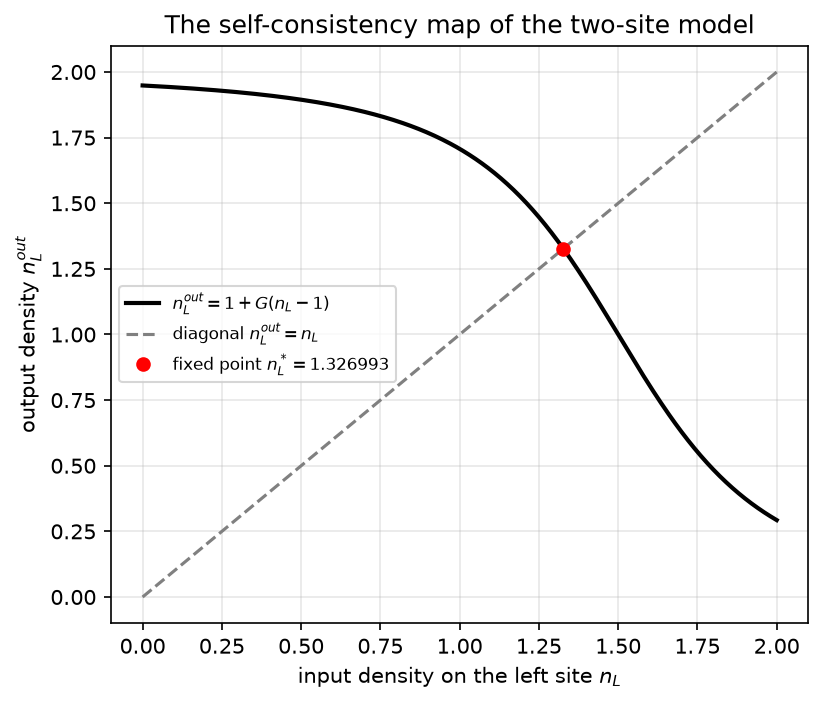

Figure 13d.1 saved as Revision/textbook/figures/13d_1_reduced_map.png


In [4]:
n_in = np.linspace(0.0, 2.0, 401)
fig, ax = plt.subplots(figsize=(6.0, 5.0))
ax.plot(n_in, 1.0 + G(n_in - 1.0), color="black", lw=2.0,
        label="$n_L^{out} = 1 + G(n_L - 1)$")
ax.plot(n_in, n_in, "--", color="gray", label="diagonal $n_L^{out} = n_L$")
ax.plot([1.0 + x_star], [1.0 + x_star], "ro",
        label=f"fixed point $n_L^* = {1.0 + x_star:.6f}$")
ax.set_xlabel("input density on the left site $n_L$")
ax.set_ylabel("output density $n_L^{out}$")
ax.set_title("The self-consistency map of the two-site model")
ax.legend(fontsize=8)
save_figure(fig, "reduced_map",
            "The output density on the left site produced by one pass of the "
            "mean-field loop, against the input density (both in electrons, from 0 "
            "to 2), for $\\Delta = 2$, $t = 1$, $U = 4$; the dashed diagonal marks "
            "equal input and output, and the red point is the self-consistent "
            "solution $n_L^\\ast = 1.326993$. The curve falls steeply through the "
            "diagonal (slope $-1.69$): more charge on the left pushes even more "
            "charge to the right.")

## 6. Plain iteration: charge sloshing

The next cell runs plain iteration ($n_L \leftarrow n_L^{out}$) from $n_L = 2$, prints
the first six passes, and then runs 2000 more passes: the input jumps between two
values forever (a cycle of period 2), never reaching the fixed point.

In [5]:
def iterate(beta, start=2.0, passes=6):
    """Inputs and outputs of the loop with linear mixing (beta = 1: plain)."""
    n, history = start, []
    for _ in range(passes):
        out = loop_pass(n)
        history.append((n, out))
        n = (1.0 - beta) * n + beta * out
    return history, n


plain, _ = iterate(1.0)
say("step   n_L in     n_L out")
for step, (n, out) in enumerate(plain):
    say(f"{step:4d}   {n:.6f}   {out:.6f}")
expected_in = [2.000000, 0.292893, 1.923880, 0.353344, 1.916644, 0.359836]
check(all(abs(n - e) < 1e-6 for (n, _), e in zip(plain, expected_in)),
      "plain iteration reproduces the table 2.000000, 0.292893, 1.923880, ...")
_, late = iterate(1.0, passes=2000)
cycle = sorted([late, loop_pass(late)])
say(f"after 2000 passes the input alternates between {cycle[0]:.4f} and "
    f"{cycle[1]:.4f}")
check(abs(loop_pass(loop_pass(late)) - late) < 1e-10 and cycle[1] - cycle[0] > 1.5,
      "plain iteration ends in a cycle of period 2 (about 0.3607 and 1.9157)")

step   n_L in     n_L out
   0   2.000000   0.292893
   1   0.292893   1.923880
   2   1.923880   0.353344
   3   0.353344   1.916644
   4   1.916644   0.359836
   5   0.359836   1.915809
PASS plain iteration reproduces the table 2.000000, 0.292893, 1.923880, ...
after 2000 passes the input alternates between 0.3607 and 1.9157
PASS plain iteration ends in a cycle of period 2 (about 0.3607 and 1.9157)


## 7. Linear mixing with beta = 1/2

The next cell prints the first six passes with $\beta = 1/2$ and counts the passes
until the input and the output agree to $10^{-6}$.

In [6]:
mixed, _ = iterate(0.5)
say("step   n_L in     n_L out")
for step, (n, out) in enumerate(mixed):
    say(f"{step:4d}   {n:.6f}   {out:.6f}")
expected_in = [2.000000, 1.146447, 1.361898, 1.314066, 1.331307, 1.325494]
check(all(abs(n - e) < 1e-6 for (n, _), e in zip(mixed, expected_in)),
      "linear mixing with beta = 1/2 reproduces the table 2.000000, 1.146447, ...")
long_history, _ = iterate(0.5, passes=40)
agree = next(step for step, (n, out) in enumerate(long_history)
             if abs(n - out) < 1e-6)
report("passes until input and output agree to 1e-6 (beta = 1/2)", agree)
check(agree == 13 and abs(long_history[-1][0] - 1.326993) < 1e-6,
      "beta = 1/2 converges to 1.326993; input and output agree after 13 passes")

step   n_L in     n_L out
   0   2.000000   0.292893
   1   1.146447   1.577350
   2   1.361898   1.266234
   3   1.314066   1.348548
   4   1.331307   1.319682
   5   1.325494   1.329519
PASS linear mixing with beta = 1/2 reproduces the table 2.000000, 1.146447, ...
RESULT passes until input and output agree to 1e-6 (beta = 1/2) = 13
PASS beta = 1/2 converges to 1.326993; input and output agree after 13 passes


The next cell draws the two iterations as cobweb diagrams: from an input on the
horizontal axis go up to the map curve (the output), then across to the mixed next
input (for plain iteration: to the diagonal), and repeat.

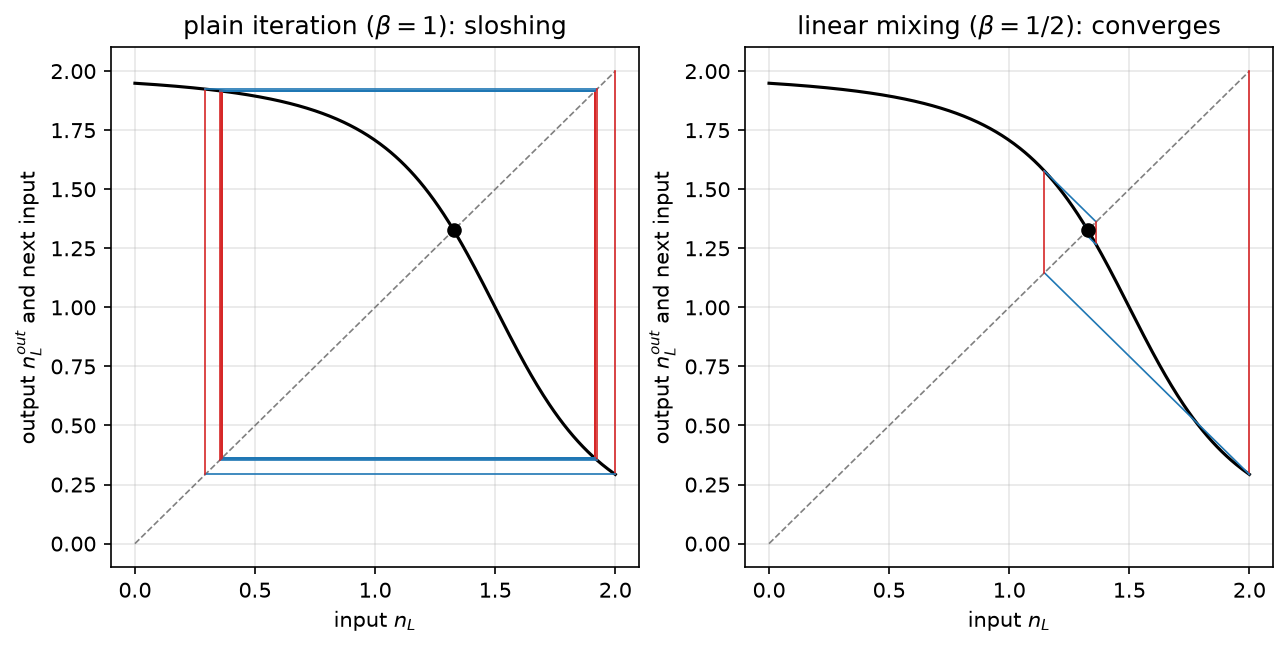

Figure 13d.2 saved as Revision/textbook/figures/13d_2_cobwebs.png


In [7]:
def cobweb(ax, beta, passes):
    """Draw the cobweb of the loop with mixing beta on the axes ax."""
    ax.plot(n_in, 1.0 + G(n_in - 1.0), color="black", lw=1.5)
    ax.plot(n_in, n_in, "--", color="gray", lw=0.8)
    history, _ = iterate(beta, passes=passes)
    for n, out in history:
        n_next = (1.0 - beta) * n + beta * out
        ax.plot([n, n], [n, out], color="tab:red", lw=0.8)  # up to the curve
        ax.plot([n, n_next], [out, n_next], color="tab:blue", lw=0.8)  # across
    ax.plot([1.0 + x_star], [1.0 + x_star], "ko")
    ax.set_xlabel("input $n_L$")
    ax.set_ylabel("output $n_L^{out}$ and next input")


fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.5))
cobweb(left, 1.0, 12)
left.set_title("plain iteration ($\\beta = 1$): sloshing")
cobweb(right, 0.5, 12)
right.set_title("linear mixing ($\\beta = 1/2$): converges")
save_figure(fig, "cobwebs",
            "Cobweb diagrams of the first 12 passes of the two-site loop, starting "
            "at $n_L = 2$: the black curve is the map (output against input), the "
            "dashed line the diagonal, red segments go from an input to its output, "
            "blue segments from the output to the next input. Left, plain "
            "iteration: the path settles on a square around the fixed point (black "
            "dot), a cycle of period 2. Right, linear mixing with $\\beta = 1/2$: "
            "the path spirals into the fixed point.")

## 8. Error histories and the convergence factor

The next cell runs the loop for $\beta = 1, 0.8, 0.5, 0.2$ and for the best value
$\beta_{best} = 0.372$, and also with Anderson mixing with the settings of the
Revision Kohn-Sham solver of the dirac16complex field, which it reads from the
solver's parameter file (how many earlier passes are remembered, and $\beta$; for
one variable Anderson mixing estimates the slope of $G$ from the last passes, like
the secant method). It records the error $|n_L - n_L^*|$ of every input and checks
the measured ratio of successive errors for $\beta = 1/2$ against the predicted
factor $1 - \beta(1 - G') = -0.344$.

In [8]:
parameters = json.loads(repository_file(
    "Revision/kohn_sham/results/parameters.json").read_text(encoding="utf-8"))
DEPTH = int(parameters["numerics"]["andersonDepth"])  # passes remembered
BETA_ANDERSON = float(parameters["numerics"]["andersonBeta"])  # mixing parameter
check(DEPTH == 6 and BETA_ANDERSON == 0.4,
      "the Revision solver mixes with depth 6 and beta 0.4 "
      "(Revision/kohn_sham/results/parameters.json, numerics)")


def errors_linear(beta, passes=60):
    """|n_L - n_L*| of the inputs of linear mixing."""
    history, _ = iterate(beta, passes=passes)
    return np.array([abs(n - 1.0 - x_star) for n, _ in history])


def errors_anderson(beta=BETA_ANDERSON, depth=DEPTH, passes=60, tolerance=1e-14):
    """|n_L - n_L*| of the inputs of Anderson mixing (one variable)."""
    n, inputs, residuals, errors = 2.0, [], [], []
    for _ in range(passes):
        errors.append(abs(n - 1.0 - x_star))
        residual = loop_pass(n) - n
        if abs(residual) < tolerance:
            break
        inputs, residuals = (inputs + [n])[-depth:], (residuals + [residual])[-depth:]
        if len(inputs) == 1:
            n = n + beta * residual
            continue
        last = residuals[-1]
        differences = np.array([[r - last for r in residuals[:-1]]])  # 1 row
        theta = np.linalg.lstsq(differences, -np.array([last]), rcond=None)[0]
        c = np.append(theta, 1.0 - theta.sum())
        n = float(sum(ci * (ni + beta * ri)
                      for ci, ni, ri in zip(c, inputs, residuals)))
    return np.array(errors)


histories = {beta: errors_linear(beta) for beta in (1.0, 0.8, 0.5, 0.2)}
histories["best"] = errors_linear(beta_best)
anderson_errors = errors_anderson()
ratio = histories[0.5][11] / histories[0.5][10]  # the ratio of two error sizes
predicted = 1.0 - 0.5 * (1.0 - g_prime)
report("measured |error ratio| for beta = 1/2", f"{ratio:.6f}")
report("predicted factor 1 - beta (1 - G')", f"{predicted:.6f}")
check(abs(ratio - abs(predicted)) < 1e-4,
      "the error shrinks by the predicted factor |1 - beta(1 - G')| = 0.344")
check(histories[1.0][-1] > 0.5 and histories[0.8][-1] > 0.1,
      "beta = 1 and beta = 0.8 (above 0.744) do not converge")
check(len(anderson_errors) < 15 and anderson_errors[-1] < 1e-12,
      "Anderson mixing converges to 1e-12 in fewer than 15 passes")

PASS the Revision solver mixes with depth 6 and beta 0.4
    (Revision/kohn_sham/results/parameters.json, numerics)
RESULT measured |error ratio| for beta = 1/2 = 0.343986
RESULT predicted factor 1 - beta (1 - G') = -0.343980
PASS the error shrinks by the predicted factor |1 - beta(1 - G')| = 0.344
PASS beta = 1 and beta = 0.8 (above 0.744) do not converge
PASS Anderson mixing converges to 1e-12 in fewer than 15 passes


The next cell draws the error histories on a logarithmic vertical axis.

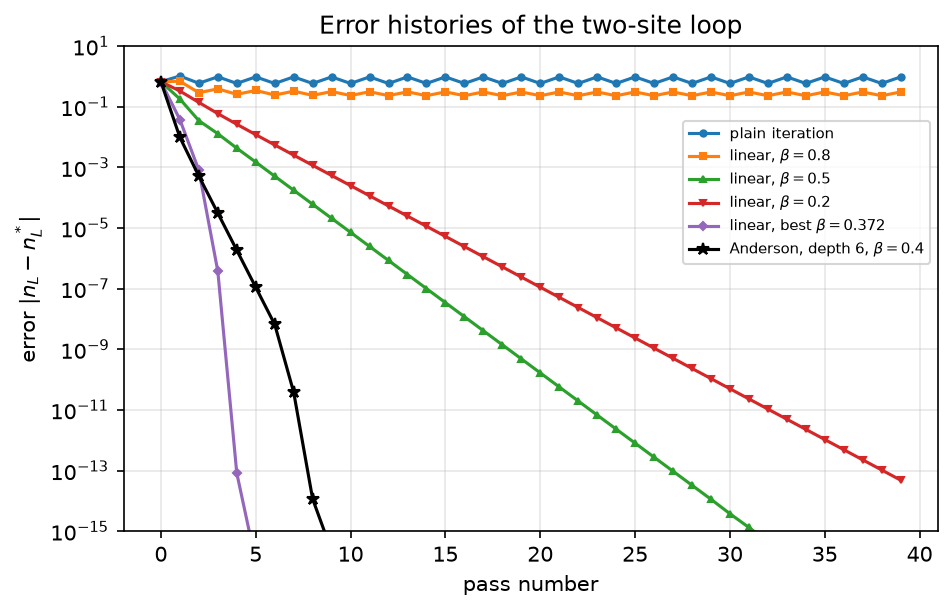

Figure 13d.3 saved as Revision/textbook/figures/13d_3_error_histories.png


In [9]:
fig, ax = plt.subplots()
for key, style in ((1.0, "o-"), (0.8, "s-"), (0.5, "^-"), (0.2, "v-")):
    label = "plain iteration" if key == 1.0 else f"linear, $\\beta = {key}$"
    ax.semilogy(histories[key][:40], style, ms=3, label=label)
best = np.maximum(histories["best"][:12], 1e-16)  # rounding may give exactly 0
ax.semilogy(best, "D-", ms=3, label=f"linear, best $\\beta = {beta_best:.3f}$")
ax.semilogy(anderson_errors, "k*-", ms=6,
            label=f"Anderson, depth {DEPTH}, $\\beta = {BETA_ANDERSON}$")
ax.set_ylim(1e-15, 10.0)
ax.set_xlabel("pass number")
ax.set_ylabel("error $|n_L - n_L^*|$")
ax.set_title("Error histories of the two-site loop")
ax.legend(fontsize=7, loc="upper right", bbox_to_anchor=(1.0, 0.86))
save_figure(fig, "error_histories",
            "The distance $|n_L - n_L^\\ast|$ of the input from the self-consistent "
            "density (logarithmic vertical axis, electrons) against the pass number "
            "for plain iteration and linear mixing with $\\beta = 0.8$ (both stay "
            "far away: sloshing), $\\beta = 0.5$ and $0.2$ (straight lines: the error "
            "shrinks by a fixed factor per pass), the best $\\beta = 0.372$ (very "
            "fast) and Anderson mixing with the Revision solver's settings (fast "
            "without knowing the slope in advance).")

The next cell draws the predicted factor $|1 - \beta(1 - G')|$ against $\beta$; the
loop converges where it is below 1.

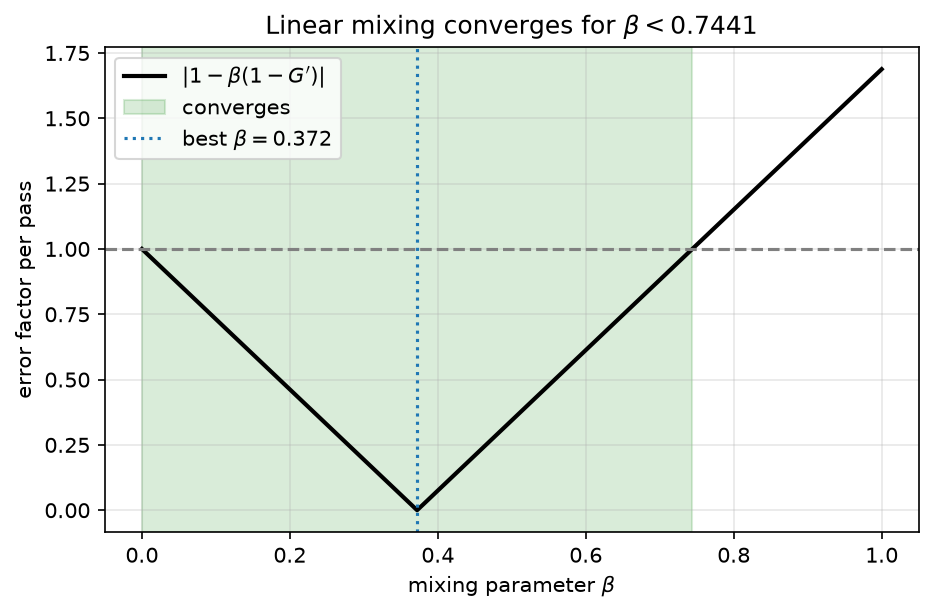

Figure 13d.4 saved as Revision/textbook/figures/13d_4_convergence_factor.png


In [10]:
betas = np.linspace(0.0, 1.0, 501)
factor = np.abs(1.0 - betas * (1.0 - g_prime))
fig, ax = plt.subplots()
ax.plot(betas, factor, color="black", lw=2.0, label="$|1 - \\beta(1 - G')|$")
ax.axhline(1.0, color="gray", ls="--")
ax.axvspan(0.0, beta_max, alpha=0.15, color="green", label="converges")
ax.axvline(beta_best, color="tab:blue", ls=":",
           label=f"best $\\beta = {beta_best:.3f}$")
ax.set_xlabel("mixing parameter $\\beta$")
ax.set_ylabel("error factor per pass")
ax.set_title(f"Linear mixing converges for $\\beta < {beta_max:.4f}$")
ax.legend()
save_figure(fig, "convergence_factor",
            "The factor $|1 - \\beta(1 - G'(x^\\ast))|$ by which one pass of linear "
            "mixing multiplies the error near the fixed point, against the mixing "
            "parameter $\\beta$ (pure numbers), for $G'(x^\\ast) = -1.688$. The loop "
            "converges where the factor is below 1 (green band, "
            "$0 < \\beta < 0.744$); the factor is zero at the best value "
            "$\\beta = 0.372$, and plain iteration ($\\beta = 1$) has the factor "
            "1.688: the error grows.")

## 9. The long run against the mixing parameter

The next cell runs the loop with 99 values of $\beta$ from 0.02 to 1 for 600
passes each and keeps the last 30 inputs. Where the loop converges they are all the
same number; where it does not, they alternate between two numbers.

PASS the loop converges below beta = 0.744 and oscillates above it


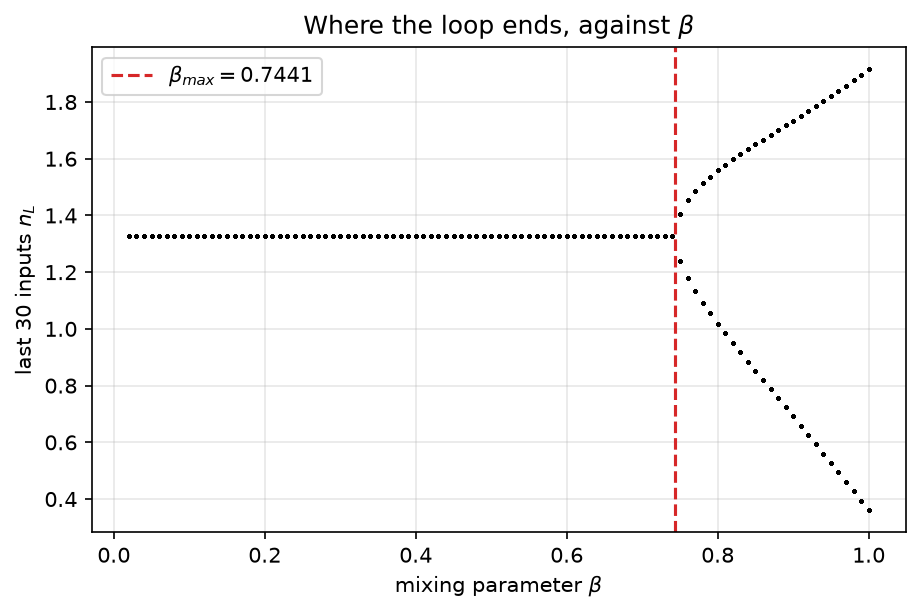

Figure 13d.5 saved as Revision/textbook/figures/13d_5_long_run_diagram.png


In [11]:
beta_scan = np.linspace(0.02, 1.0, 99)
tails = []
for beta in beta_scan:
    history, _ = iterate(beta, passes=600)
    tails.append([n for n, _ in history[-30:]])
tails = np.array(tails)
spread = tails.max(axis=1) - tails.min(axis=1)
check(np.all(spread[beta_scan < 0.72] < 1e-8) and np.all(spread[beta_scan > 0.77]
                                                        > 0.05),
      "the loop converges below beta = 0.744 and oscillates above it")
fig, ax = plt.subplots()
for beta, tail in zip(beta_scan, tails):
    ax.plot(np.full(len(tail), beta), tail, "k.", ms=2)
ax.axvline(beta_max, color="tab:red", ls="--", label=f"$\\beta_{{max}} = "
           f"{beta_max:.4f}$")
ax.set_xlabel("mixing parameter $\\beta$")
ax.set_ylabel("last 30 inputs $n_L$")
ax.set_title("Where the loop ends, against $\\beta$")
ax.legend()
save_figure(fig, "long_run_diagram",
            "The last 30 inputs $n_L$ (electrons) of 600 passes of the two-site loop "
            "for 99 mixing parameters $\\beta$ from 0.02 to 1 (horizontal axis). "
            "Below $\\beta_{max} = 0.744$ (dashed red line) all points coincide at "
            "the self-consistent density 1.327; above it the loop ends in a cycle "
            "of period 2 whose two values move apart as $\\beta$ grows, reaching "
            "0.36 and 1.92 for plain iteration.")

## 10. A weaker repulsion, and the threshold against U

With $U = 2$ the slope at the fixed point is milder, and $\beta_{max} > 1$: even
plain iteration converges (slowly, alternating). The next cell checks the numbers
$x^* = 0.468990$, $G' = -0.688942$, $\beta_{max} = 1.184174$, and then computes
$\beta_{max}$ for repulsions from 0.5 to 8, and finds by bisection the repulsion at
which plain iteration stops converging ($\beta_{max} = 1$, i.e. $G'(x^*) = -1$).

In [12]:
x2 = fixed_point(u=2.0)
g2 = slope(x2, u=2.0)
report("U = 2: n_L*", f"{1.0 + x2:.6f}")
report("U = 2: G'(x*)", f"{g2:.6f}")
report("U = 2: beta_max", f"{2.0 / (1.0 - g2):.6f}")
check(abs(x2 - 0.468990) < 1e-6 and abs(g2 + 0.688942) < 1e-6
      and abs(2.0 / (1.0 - g2) - 1.184174) < 1e-6,
      "U = 2: x* = 0.468990, G' = -0.688942, beta_max = 1.184174")
n = 2.0
for _ in range(200):  # plain iteration with U = 2
    n = loop_pass(n, u=2.0)
check(abs(n - 1.0 - x2) < 1e-10, "U = 2: plain iteration converges")
U_scan = np.linspace(0.5, 8.0, 76)
beta_limits = np.array([2.0 / (1.0 - slope(fixed_point(u=u), u=u)) for u in U_scan])
low, high = 2.0, 4.0  # beta_max(2) > 1 > beta_max(4)
for _ in range(60):
    middle = 0.5 * (low + high)
    if 2.0 / (1.0 - slope(fixed_point(u=middle), u=middle)) > 1.0:
        low = middle
    else:
        high = middle
U_critical = 0.5 * (low + high)
report("repulsion where plain iteration stops converging", f"{U_critical:.6f}")
check(abs(slope(fixed_point(u=U_critical), u=U_critical) + 1.0) < 1e-9,
      "at this repulsion the slope at the fixed point is exactly -1")

RESULT U = 2: n_L* = 1.468990
RESULT U = 2: G'(x*) = -0.688942
RESULT U = 2: beta_max = 1.184174
PASS U = 2: x* = 0.468990, G' = -0.688942, beta_max = 1.184174
PASS U = 2: plain iteration converges
RESULT repulsion where plain iteration stops converging = 2.647393
PASS at this repulsion the slope at the fixed point is exactly -1


The next cell draws $\beta_{max}$ against $U$.

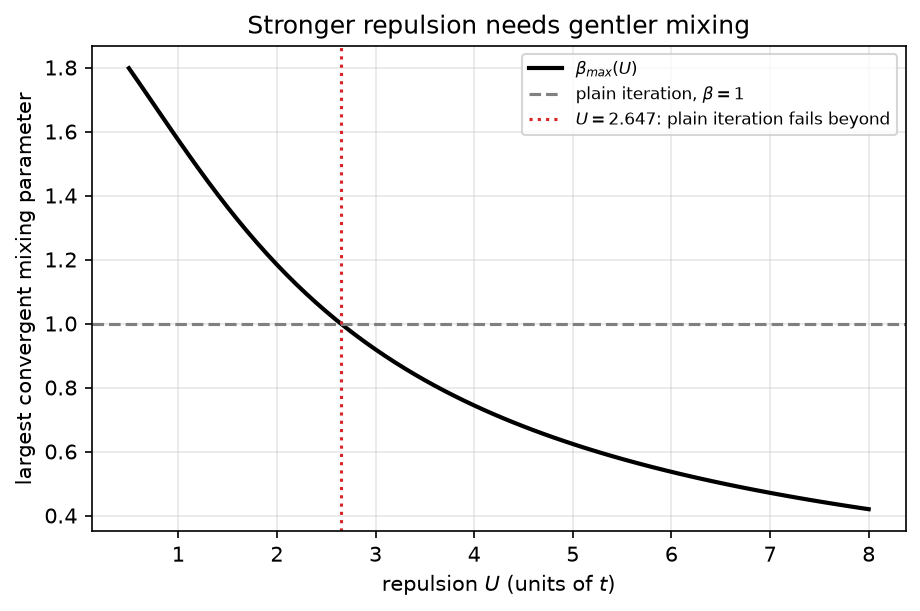

Figure 13d.6 saved as Revision/textbook/figures/13d_6_threshold_versus_u.png


In [13]:
fig, ax = plt.subplots()
ax.plot(U_scan, beta_limits, color="black", lw=2.0, label="$\\beta_{max}(U)$")
ax.axhline(1.0, color="gray", ls="--", label="plain iteration, $\\beta = 1$")
ax.axvline(U_critical, color="tab:red", ls=":",
           label=f"$U = {U_critical:.3f}$: plain iteration fails beyond")
ax.set_xlabel("repulsion $U$ (units of $t$)")
ax.set_ylabel("largest convergent mixing parameter")
ax.set_title("Stronger repulsion needs gentler mixing")
ax.legend(fontsize=8)
save_figure(fig, "threshold_versus_u",
            "The largest mixing parameter $\\beta_{max} = 2/(1 - G'(x^\\ast))$ for "
            "which linear mixing converges, against the repulsion $U$ (units of "
            "$t$; $\\Delta = 2$, $t = 1$). Below the dashed line $\\beta = 1$ plain "
            "iteration fails; this happens beyond the repulsion marked by the "
            "dotted line. The stronger the feedback of the density on its own "
            "potential, the smaller the step the loop may take.")

## 11. The last check

The last cell checks that all six figure files exist and prints the number of
checks that passed.

In [14]:
figure_names = ["reduced_map", "cobwebs", "error_histories", "convergence_factor",
                "long_run_diagram", "threshold_versus_u"]
missing = [name for k, name in enumerate(figure_names, 1)
           if not output_file(f"{FIGURE_FOLDER}/13d_{k}_{name}.png").is_file()]
check(missing == [], "all six figure files exist")
check(output_file(f"{FIGURE_FOLDER}/13d_6_threshold_versus_u.png").is_file(),
      "the figure file 13d_6_threshold_versus_u.png exists")
all_checks_passed()

PASS all six figure files exist
PASS the figure file 13d_6_threshold_versus_u.png exists
ALL 17 CHECKS PASSED (notebook 13d)


## 12. What this notebook showed

- The whole self-consistency loop of the two-site mean-field model is one function
  $G(x) = (\Delta - Ux)/\sqrt{(\Delta - Ux)^2 + 4t^2}$ of one number, and its fixed
  point is the self-consistent density $n_L^* = 1.326993$.
- Plain iteration fails: the charge jumps between the sites forever (a cycle of
  period 2 near 0.3607 and 1.9157), because the slope $G'(x^*) = -1.688$ is steeper
  than $-1$.
- Linear mixing converges exactly for $0 < \beta < 2/(1 - G') = 0.744058$; each pass
  multiplies the error by $1 - \beta(1 - G')$ ($-0.344$ for $\beta = 1/2$), and
  $\beta = 1/(1 - G') = 0.372$ is the fastest.
- Anderson mixing, which estimates the slope from earlier passes, converges in a
  few passes without tuning; the Revision Kohn-Sham solver of the dirac16complex
  field uses it with depth 6 and $\beta = 0.4$ (read here from its parameter file).
- The stronger the repulsion, the smaller the step the loop may take; for
  $\Delta = 2$, $t = 1$ plain iteration converges only for $U$ below the printed
  threshold (for example $U = 2$: $\beta_{max} = 1.184$).